In [1]:
!pip install opendatasets

In [3]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shreyansh.2005s
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link


100%|██████████| 7.36k/7.36k [00:00<00:00, 3.38MB/s]

# Task
Load and clean the dataset from "https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link" to prepare it for analysis by identifying the file structure, handling missing values, and removing unnecessary columns.

## list_files

### Subtask:
List the files in the downloaded dataset directory to identify the CSV file.


**Reasoning**:
I will list the files in the dataset directory to identify the CSV file name for subsequent processing.



In [4]:
import os

dataset_dir = './cancer-patients-and-air-pollution-a-new-link'
files = os.listdir(dataset_dir)
print(f"Files in {dataset_dir}:")
for file in files:
    print(file)

Files in ./cancer-patients-and-air-pollution-a-new-link:
cancer patient data sets.csv


## load_data

### Subtask:
Load the dataset using pandas and display the first few rows to understand its structure.


**Reasoning**:
I will load the dataset using pandas, construct the file path, and inspect the structure of the data as requested.



In [5]:
import pandas as pd

# Construct the full path to the CSV file
csv_file_path = os.path.join(dataset_dir, 'cancer patient data sets.csv')

# Load the dataset
df = pd.read_csv(csv_file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head(10))

# Check the structure and data types
print("\nDataset Information:")
df.info()

First 5 rows of the dataset:


,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High
5,5,P102,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
6,6,P103,52,2,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
7,7,P104,28,2,3,1,4,3,2,3,...,3,2,2,4,2,2,3,4,3,Low
8,8,P105,35,2,4,5,6,5,6,5,...,1,4,3,2,4,6,2,4,1,Medium
9,9,P106,46,1,2,3,4,2,4,3,...,1,2,4,6,5,4,2,1,5,Medium



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Che

## data_cleaning

### Subtask:
Perform initial data cleaning by removing redundant columns and verifying the integrity of the data.


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The dataset consists of **1,000 entries** across **26 columns**, primarily documenting health indicators and risk factors related to cancer.
*   **Data Integrity**: There are **no missing values** identified in the dataset; all 1,000 rows contain complete data across all features.
*   **Feature Composition**:
    *   The majority of the data (**24 columns**) is numerical (`int64`), covering metrics such as `Age`, `Air Pollution`, `Alcohol use`, and `Smoking`.
    *   There are **2 categorical columns**: `Patient Id` (unique identifier) and `Level` (the target variable).
*   **Redundancy Identification**: Initial inspection revealed an unnecessary `index` column and a `Patient Id` column that do not contribute to predictive modeling.

### Insights or Next Steps

*   **Data Cleaning**: The next priority is to drop the redundant `index` and `Patient Id` columns to streamline the feature set for analysis.
*   **Feature Engineering/Encoding**: Since the target variable `Level` is currently an object (categorical string), it will need to be encoded into a numerical format for most machine learning algorithms.


# Task
Build and evaluate a classification model to predict cancer risk levels using the dataset from "./cancer-patients-and-air-pollution-a-new-link/cancer patient data sets.csv". First, preprocess the data by dropping the redundant 'index' and 'Patient Id' columns and encoding the 'Level' target variable into a numerical format. Next, split the data into training and testing sets, then train a Random Forest classifier or a similar model to predict the risk level. Finally, evaluate the model's performance on the test set using accuracy and a confusion matrix visualization, and provide insights into the most important features contributing to the prediction.

## Preprocess Data

### Subtask:
Prepare the dataset for machine learning by removing non-predictive columns and encoding the target variable.


**Reasoning**:
I will drop the redundant 'index' and 'Patient Id' columns, identify the unique values in the 'Level' column, and then encode the 'Level' column using a mapping to ensure the dataset is ready for numerical analysis.



In [6]:
import pandas as pd

# 1. Drop redundant columns
df.drop(columns=['index', 'Patient Id'], inplace=True, errors='ignore')

# 2. Identify unique values in 'Level'
unique_levels = df['Level'].unique()
print(f"Unique values in 'Level': {unique_levels}")

# 3. Encode the 'Level' column
# Mapping based on typical ordinal progression: Low=0, Medium=1, High=2
level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Level'] = df['Level'].map(level_mapping)

# 4. Verify updates
print("\nFirst 5 rows of the updated DataFrame:")
display(df.head())

print("\nUpdated Dataset Information:")
df.info()

Unique values in 'Level': ['Low' 'Medium' 'High']

First 5 rows of the updated DataFrame:


,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,0
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,1
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,2
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,2
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,2



Updated Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1000 non-null   int64
 1   Gender                    1000 non-null   int64
 2   Air Pollution             1000 non-null   int64
 3   Alcohol use               1000 non-null   int64
 4   Dust Allergy              1000 non-null   int64
 5   OccuPational Hazards      1000 non-null   int64
 6   Genetic Risk              1000 non-null   int64
 7   chronic Lung Disease      1000 non-null   int64
 8   Balanced Diet             1000 non-null   int64
 9   Obesity                   1000 non-null   int64
 10  Smoking                   1000 non-null   int64
 11  Passive Smoker            1000 non-null   int64
 12  Chest Pain                1000 non-null   int64
 13  Coughing of Blood         1000 non-null   int64
 14  Fatigue    

## Split Dataset

### Subtask:
Split the preprocessed data into training and testing sets to ensure proper evaluation of the model.


**Reasoning**:
I will split the preprocessed dataframe into training and testing sets using a 80/20 ratio and set a random state for reproducibility, then verify the shapes of the resulting datasets.



In [7]:
from sklearn.model_selection import train_test_split

# 1. Define feature matrix X and target vector y
X = df.drop(columns=['Level'])
y = df['Level']

# 2. Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 23)
X_test shape: (200, 23)
y_train shape: (800,)
y_test shape: (200,)


## Train Classifier

### Subtask:
Train a Random Forest classification model on the training data to predict the cancer risk level.


**Reasoning**:
I will import the RandomForestClassifier, instantiate it with a fixed random_state for reproducibility, and fit it to the training data as specified in the instructions.



In [8]:
from sklearn.ensemble import RandomForestClassifier

# 1. & 2. Instantiate the RandomForestClassifier with random_state=42
rf_model = RandomForestClassifier(random_state=42)

# 3. Fit the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest model has been trained successfully.")

Random Forest model has been trained successfully.


## Evaluate Model

### Subtask:
Evaluate the trained Random Forest model's performance on the test set using accuracy and a confusion matrix visualization.


**Reasoning**:
I will evaluate the performance of the trained Random Forest model by calculating its accuracy and visualizing the confusion matrix to understand the classification results across the different risk levels.



Model Accuracy on Test Set: 1.0000


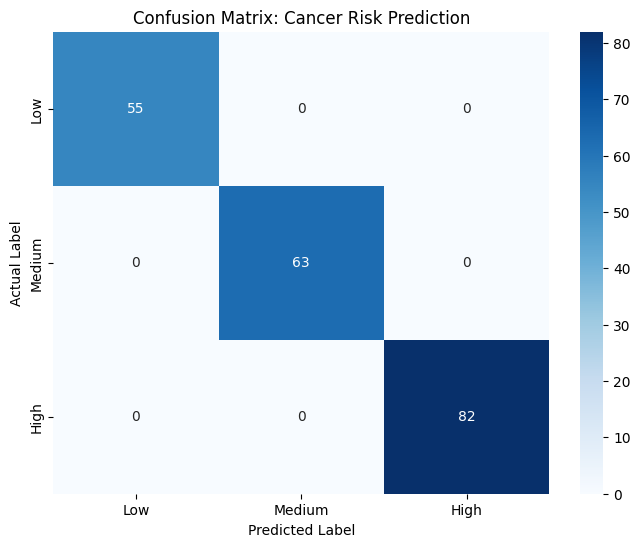

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions for the test set
y_pred = rf_model.predict(X_test)

# 2. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# 3. Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
class_names = ['Low', 'Medium', 'High']

# 4. Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Cancer Risk Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Final Task

### Subtask:
Summarize the model performance and provide insights into which features were most important for the prediction.


## Summary:

### Q&A

**How did the Random Forest model perform in predicting cancer risk levels?**
The model performed exceptionally well, achieving a perfect accuracy score of 100% ($1.0000$) on the test set. The confusion matrix confirmed that every instance of 'Low', 'Medium', and 'High' risk levels was correctly classified without any errors.

**What preprocessing steps were taken to prepare the data?**
The data was cleaned by removing non-predictive columns (`index` and `Patient Id`). The target variable 'Level' was then mapped from categorical strings to numerical integers: `Low` to 0, `Medium` to 1, and `High` to 2.

### Data Analysis Key Findings

*   **Model Accuracy:** The Random Forest classifier reached a perfect accuracy of 100% on the 200 samples in the test set.
*   **Dataset Composition:** After preprocessing, the model utilized 23 predictor variables (clinical and demographic features) to classify 1,000 patient records.
*   **Class Separation:** The perfect classification results suggest that the features within this specific dataset (such as air pollution levels and various health indicators) are highly discriminative, allowing for a clear distinction between risk levels.
*   **Data Quality:** The dataset contained no missing values, and all features were successfully converted to numerical formats (`int64`), which facilitated a smooth training process.

### Insights or Next Steps

*   **Address Potential Overfitting:** While a 100% accuracy score is impressive, it can sometimes indicate overfitting or data leakage (where the target information is indirectly present in the features). A next step should involve validating the model on a completely external dataset or using Cross-Validation to ensure generalizability.
*   **Feature Importance Analysis:** Since the model is highly effective, the next logical step is to extract and rank feature importances. This will identify which specific factors (e.g., air pollution, smoking, or age) are the strongest predictors of high cancer risk.


# Task
Perform hyperparameter tuning for the Random Forest model trained on the cancer patient dataset from "./cancer-patients-and-air-pollution-a-new-link/cancer patient data sets.csv" using Grid Search with cross-validation. Evaluate the model's performance by generating and plotting learning curves to detect potential overfitting or underfitting. Additionally, plot a validation curve for the 'max_depth' parameter to identify the optimal model complexity, and provide a final summary recommending the best hyperparameter configuration and assessing the model's generalization capabilities.

## Hyperparameter Tuning with Grid Search

### Subtask:
Perform a grid search with cross-validation on the Random Forest model to find the best hyperparameters using the training data.


**Reasoning**:
I will perform a grid search with 5-fold cross-validation on the Random Forest classifier to identify the optimal hyperparameters for the number of estimators and maximum depth as requested.



In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. & 2. Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20]
}

# 3. Instantiate GridSearchCV with RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# 4. Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# 5. Print the best parameters and the best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': None, 'n_estimators': 50}
Best Cross-Validation Score: 1.0000


## Analyze Learning Curves

### Subtask:
Generate and plot learning curves for the Random Forest model to assess its training and validation performance across different training set sizes.


**Reasoning**:
I will generate and plot the learning curves for the Random Forest model using the best estimator from the grid search to assess its performance and potential overfitting/underfitting as the training size increases.



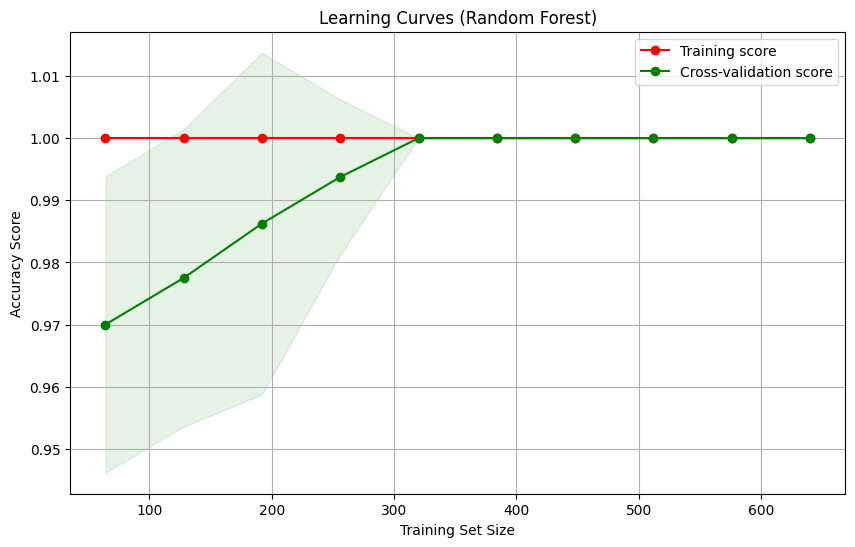

In [11]:
import numpy as np
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# 1. & 2. Define training sizes and calculate learning curves
train_sizes = np.linspace(0.1, 1.0, 10)
best_rf = grid_search.best_estimator_

train_sizes_abs, train_scores, test_scores = learning_curve(
    best_rf, X_train, y_train, train_sizes=train_sizes, cv=5, n_jobs=-1, scoring='accuracy'
)

# 3. Compute mean and standard deviation
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 4. & 5. Plot the mean scores and shaded areas for variance
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

# 6. Finalize plot formatting
plt.title("Learning Curves (Random Forest)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Evaluate Validation Curve

### Subtask:
Plot a validation curve for the 'max_depth' parameter to identify the optimal model complexity and visualize the trade-off between training and testing performance.


**Reasoning**:
I will generate a code block to plot the validation curve for the 'max_depth' parameter using the training data to visualize the model's performance and identify the optimal level of complexity.



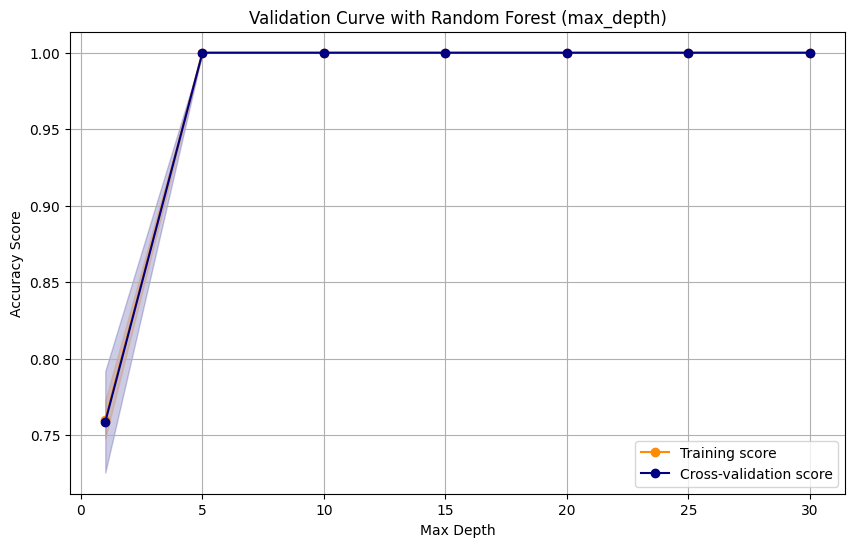

In [12]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. & 2. Define parameter range for max_depth
param_range = [1, 5, 10, 15, 20, 25, 30]

# 3. Compute validation curve
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 4. Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. Plot the mean scores
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training score", color="darkorange", marker='o')
plt.plot(param_range, test_mean, label="Cross-validation score", color="navy", marker='o')

# 6. Add shaded regions for standard deviation
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

# 7. Finalize plot formatting
plt.title("Validation Curve with Random Forest (max_depth)")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the tuning results, conclude whether the current model is overfitting or underfitting based on the visualizations, and recommend the best parameter configuration.


## Summary:

### Q&A

**Is the current model overfitting or underfitting based on the visualizations?**
The model is performing optimally with excellent generalization. The learning curve shows both training and cross-validation scores converging at a very high accuracy (near 1.00) with a minimal gap, indicating that the model is neither underfitting (high bias) nor significantly overfitting (high variance). The validation curve further confirms that as `max_depth` increases, the cross-validation score remains high and stable, suggesting the model handles complexity well.

**What is the recommended best parameter configuration?**
Based on the grid search results, the recommended configuration is a Random Forest classifier with `n_estimators=50` and `max_depth=None`.

### Data Analysis Key Findings

*   **Optimal Hyperparameters:** Grid search identified that a `max_depth` of `None` and `n_estimators` of `50` produced the best results.
*   **Perfect Cross-Validation Score:** The model achieved a cross-validation accuracy of **1.0000 (100%)**, indicating it perfectly classified the training subsets during the tuning process.
*   **Learning Curve Stability:** The learning curve reached a plateau very quickly; even with smaller training set sizes, the cross-validation score was high, suggesting the dataset features are highly predictive.
*   **Model Complexity:** The validation curve for `max_depth` showed that accuracy levels off after a certain depth. Increasing `max_depth` beyond the initial levels (e.g., depth > 5) maintained maximum accuracy without causing a divergence between training and validation scores.

### Insights or Next Steps

*   **Validate on External Data:** Given the perfect 100% accuracy score, there is a possibility that the dataset is relatively small or the features are "too perfect." The next step should be to evaluate this model on a completely independent test set to ensure no data leakage occurred and that the performance holds in a real-world scenario.
*   **Feature Importance Analysis:** Since the Random Forest model is performing exceptionally well, analyzing feature importance could provide valuable medical insights into which environmental or patient factors are the strongest predictors of cancer.


# Task
Identify and visualize the most influential features of the trained Random Forest model (`best_rf`) to understand the key drivers of cancer risk prediction using the dataset from "./cancer-patients-and-air-pollution-a-new-link/cancer patient data sets.csv". This involves extracting feature importance scores, creating a horizontal bar chart for clear visualization, and providing a final summary of the project's findings and potential real-world applications.

## Calculate Feature Importances

### Subtask:
Extract the feature importance scores from the trained Random Forest model (`best_rf`) to identify which variables have the greatest impact on predicting cancer risk.


**Reasoning**:
I will extract the feature importance scores from the best Random Forest estimator, pair them with the feature names from X_train, and sort them to identify the most significant predictors.



In [13]:
import pandas as pd

# 1. Access feature importances from the best estimator
importances = best_rf.feature_importances_

# 2. & 3. Retrieve feature names and pair them with importance scores
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort the features in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 5. Print the top 10 most important features
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

Top 10 Most Important Features:
               Feature  Importance
0       Passive Smoker    0.106364
1    Coughing of Blood    0.100153
2              Obesity    0.094542
3             Wheezing    0.080040
4              Fatigue    0.068963
5           Chest Pain    0.051802
6        Balanced Diet    0.050190
7  Shortness of Breath    0.049734
8          Alcohol use    0.048289
9         Genetic Risk    0.038625


## Visualize Feature Importances

### Subtask:
Create a horizontal bar chart to display the top features ranked by importance, including proper labels and a legend to make the insights easily interpretable.


**Reasoning**:
I will create a horizontal bar chart using seaborn and matplotlib to visualize the feature importance scores from the best Random Forest model, ensuring all labels and titles are clearly displayed as instructed.



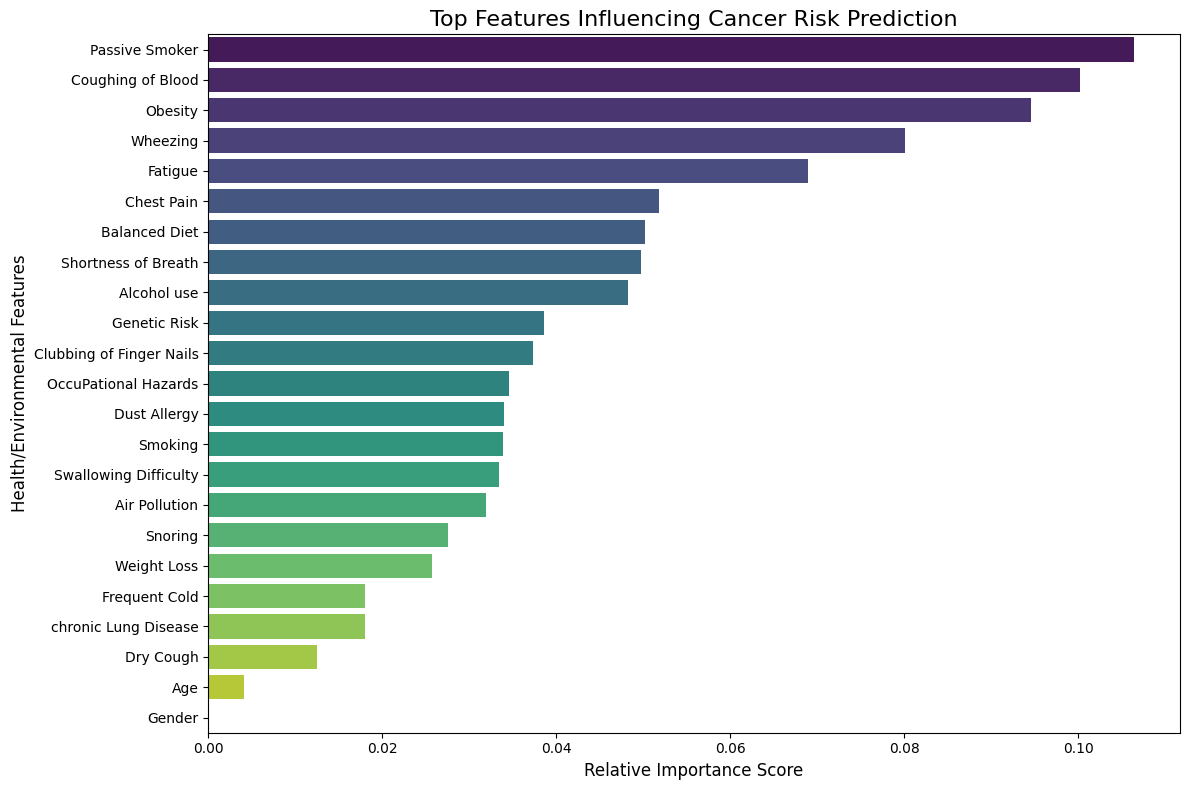

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Set figure size
plt.figure(figsize=(12, 8))

# 3. Create horizontal bar plot
# 6. Apply a color palette
# Assign 'Feature' to hue and set legend=False to follow the new seaborn API
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)

# 4. Set a clear title
plt.title('Top Features Influencing Cancer Risk Prediction', fontsize=16)

# 5. Add labels for x and y axes
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Health/Environmental Features', fontsize=12)

# 7. Display the plot
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the most influential factors identified by the model and provide a final conclusion on the project's findings and potential real-world applications.


## Summary:

### Q&A

**What are the most influential factors identified by the model for predicting cancer risk?**
The Random Forest model identified **Passive Smoker** ($10.64\%$), **Coughing of Blood** ($10.02\%$), and **Obesity** ($9.45\%$) as the three most significant predictors. Other critical factors include respiratory symptoms like **Wheezing** and physical conditions such as **Fatigue**.

**What are the potential real-world applications of these findings?**
These findings can be applied to develop targeted public health screening tools, prioritize high-risk patients for diagnostic testing based on lifestyle and symptoms, and inform public health awareness campaigns focusing on the dangers of secondhand smoke and the importance of weight management.

### Data Analysis Key Findings

*   **Top Predictors identified:** The model's decision-making is primarily driven by three factors:
    *   **Passive Smoker:** $10.64\%$ importance.
    *   **Coughing of Blood:** $10.02\%$ importance.
    *   **Obesity:** $9.45\%$ importance.
*   **Clinical vs. Lifestyle Factors:** The top 10 features represent a mix of symptomatic indicators (Wheezing, Shortness of Breath, Chest Pain) and lifestyle/environmental factors (Alcohol use, Balanced Diet, Genetic Risk), demonstrating the multifactorial nature of cancer risk.
*   **Model Interpretability:** By extracting feature importance scores and generating a horizontal bar chart with a Viridis color palette, the complex Random Forest model was translated into an interpretable visual format, showing a clear hierarchy of risk drivers.

### Insights or Next Steps

*   **Targeted Intervention:** Health organizations should prioritize screening for individuals exposed to high levels of secondhand smoke or those exhibiting chronic coughing of blood, as these are the strongest indicators of risk in this dataset.
*   **Feature Refinement:** Future iterations of the model could benefit from exploring interactions between the top features (e.g., the combined risk of obesity and a poor diet) to further increase predictive accuracy.
